Cognitive Decline Risk Prediction: A Neural Network Approach with Vectorized Implementation

Data and statistical analysis

Step 1: Importing the required libraries

In [193]:
# importing the libraries
# importing the csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Step 2: Load the dataset and initial exploration

In [194]:
data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv")

# basic dataset info

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns.tolist())
print("\nData Types:")
print(data.dtypes)


Dataset shape: (11000, 19)

First 5 rows:
   Age  Gender Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   29  Female     Artist          6.0                           2.7   
1   46   Other      Nurse          6.2                           5.7   
2   64    Male      Other          5.0                           3.7   
3   20  Female  Scientist          5.8                           2.8   
4   49  Female      Other          8.2                           2.3   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week) Smoking  \
0                       181                                 10     Yes   
1                       200                                  8     Yes   
2                       117                                  4      No   
3                       360                                  6     Yes   
4                       247                                  4     Yes   

  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0         

Descriptive statistics

In [195]:
# Basic descriptive statistics for numerical variables
desc_stats = data.describe(include=[np.number])
print("Descriptive Statistics (Numerical Variables):")
print(desc_stats)
print("\n" + "="*50)



Descriptive Statistics (Numerical Variables):
                Age   Sleep Hours  Physical Activity (hrs/week)  \
count  11000.000000  11000.000000                  11000.000000   
mean      40.241727      6.650691                      2.942136   
std       13.236140      1.227509                      1.827825   
min       18.000000      2.300000                      0.000000   
25%       29.000000      5.900000                      1.500000   
50%       40.000000      6.700000                      2.800000   
75%       51.000000      7.500000                      4.200000   
max       64.000000     11.300000                     10.100000   

       Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week)  \
count              11000.000000                       11000.000000   
mean                 286.090000                           9.701636   
std                  144.813157                           5.689713   
min                    0.000000                           0.000000   


In [196]:
# For categorical variables
cat_stats = data.describe(include=['object'])
print("Descriptive Statistics (Categorical Variables):")
print(cat_stats)

Descriptive Statistics (Categorical Variables):
        Gender Occupation Smoking Family History of Anxiety Dizziness  \
count    11000      11000   11000                     11000     11000   
unique       3         13       2                         2         2   
top     Female   Musician     Yes                       Yes       Yes   
freq      3730        892    5779                      5847      5672   

       Medication Recent Major Life Event  
count       11000                   11000  
unique          2                       2  
top           Yes                     Yes  
freq         5666                    5623  


Missing values analysis

In [197]:
data.isnull().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

Missing Value Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


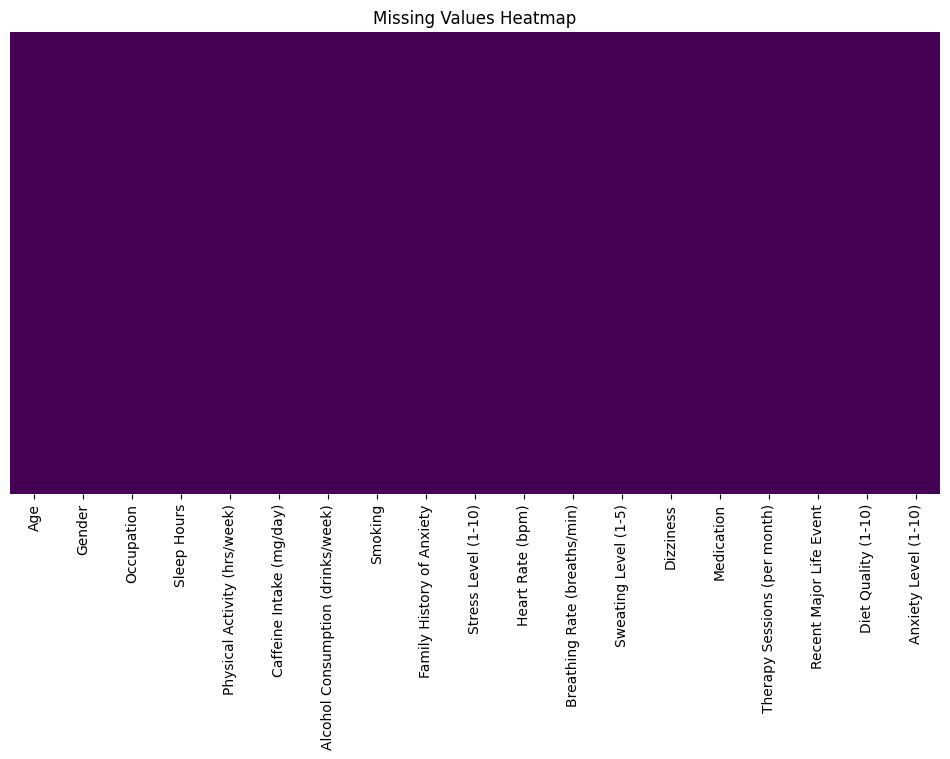

In [198]:
# Missing values summary
missing_data = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data = missing_data.sort_values('Percentage', ascending=False)

print("Missing Value Analysis:")
print(missing_data)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

CORRELATION ANALYSIS

/tmp/ipykernel_2942/1971763681.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Yes': 1, 'No': 0})


Number of numeric columns: 17
Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='object')


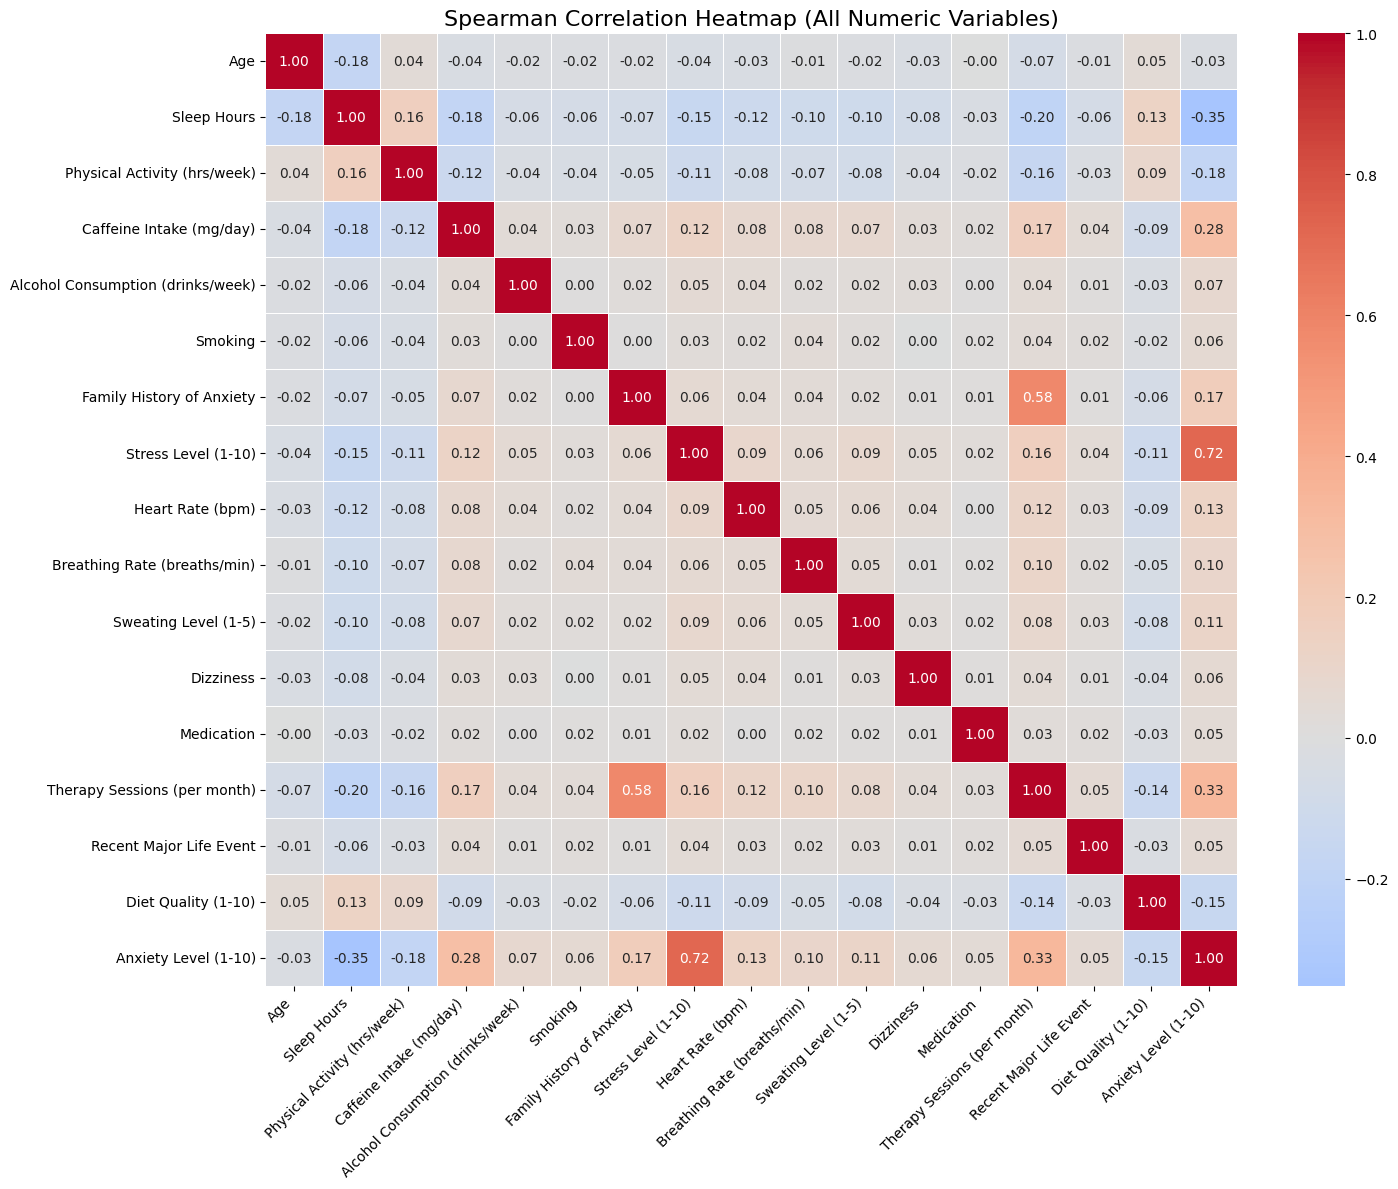

In [199]:

# 2️ Convert Yes/No columns to 1/0 (DO NOT overwrite data)
yes_no_cols = [
    'Smoking',
    'Family History of Anxiety',
    'Dizziness',
    'Medication',
    'Recent Major Life Event'
]

data[yes_no_cols] = (
    data[yes_no_cols]
    .replace({'Yes': 1, 'No': 0})
    .infer_objects(copy=False)
)

# 3️ Select ALL numeric columns (should be 18)
numeric_data = data.select_dtypes(include=['int64', 'float64'])

print(f"Number of numeric columns: {numeric_data.shape[1]}")
print(numeric_data.columns)

# 4️ Compute Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# 5️ Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap (All Numeric Variables)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Highly correlated columns:
['Sleep Hours', 'Stress Level (1-10)', 'Therapy Sessions (per month)', 'Anxiety Level (1-10)']


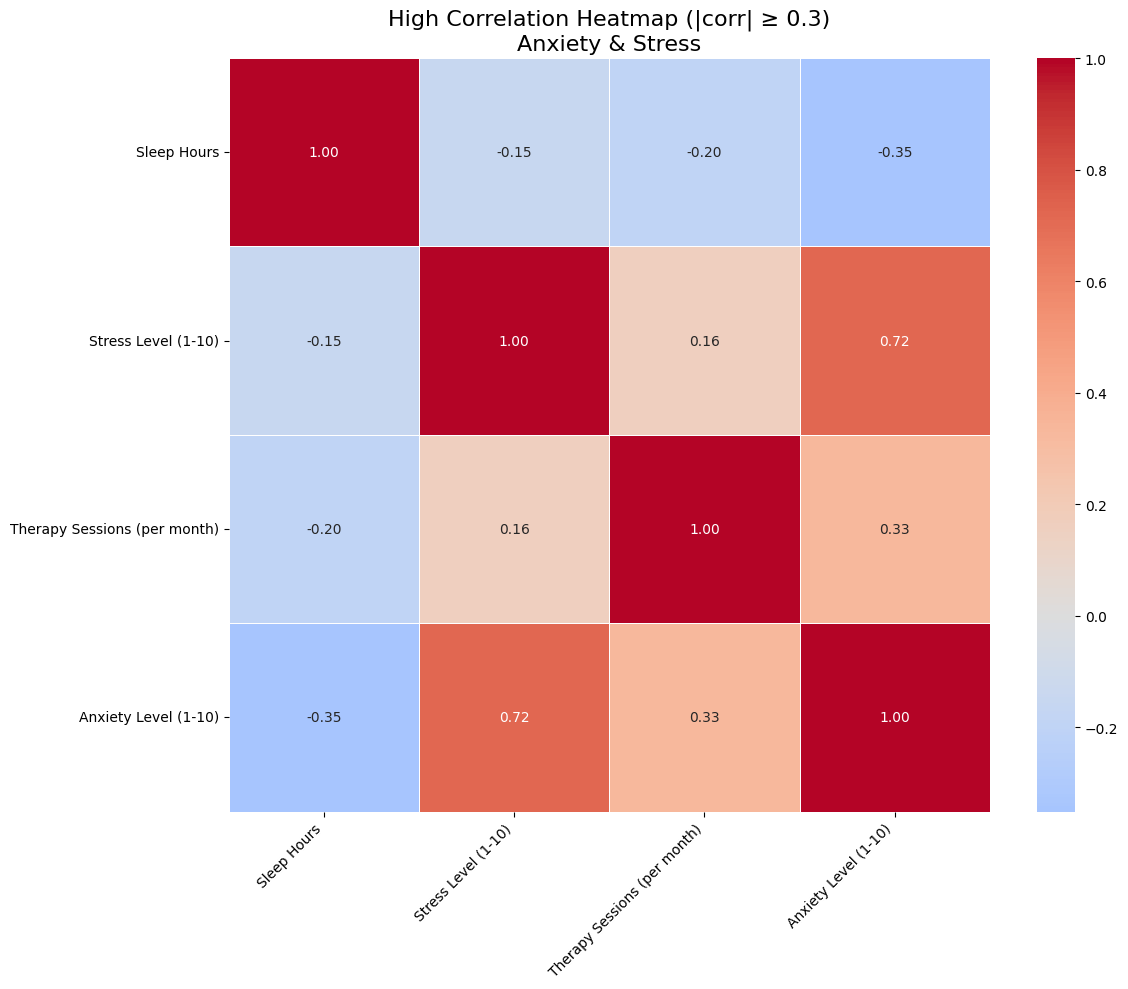

In [200]:
# Select numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# Set correlation threshold
threshold = 0.3

# Find columns highly correlated with Anxiety or Stress
target_cols = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

high_corr_cols = corr_matrix[
    target_cols
].abs().max(axis=1)

high_corr_cols = high_corr_cols[high_corr_cols >= threshold].index.tolist()

print("Highly correlated columns:")
print(high_corr_cols)

# Filter correlation matrix
filtered_corr = corr_matrix.loc[high_corr_cols, high_corr_cols]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    f"High Correlation Heatmap (|corr| ≥ {threshold})\nAnxiety & Stress",
    fontsize=16
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Multi-Target Correlation Table:
                                   Anxiety Level (1-10)  Stress Level (1-10)  \
Sleep Hours                                   -0.351404            -0.154266   
Therapy Sessions (per month)                   0.330756             0.164721   
Caffeine Intake (mg/day)                       0.282222             0.123665   
Physical Activity (hrs/week)                  -0.180975            -0.112031   
Family History of Anxiety                      0.171422             0.061151   
Diet Quality (1-10)                           -0.150998            -0.112294   
Heart Rate (bpm)                               0.126017             0.089340   
Sweating Level (1-5)                           0.108343             0.085574   
Breathing Rate (breaths/min)                   0.100656             0.062793   
Alcohol Consumption (drinks/week)              0.073008             0.052601   
Dizziness                                      0.064323             0.047799   
Smoking 

<Figure size 1200x800 with 0 Axes>

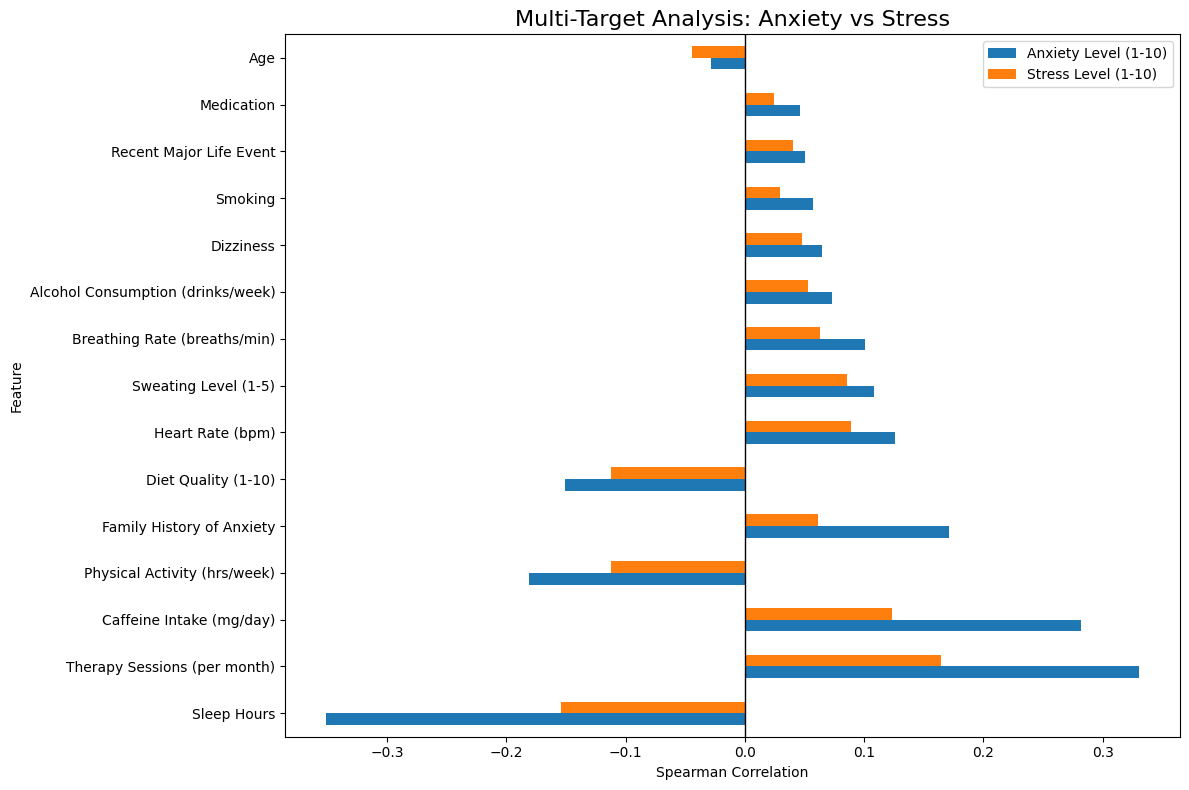

In [201]:

# Define targets
targets = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

# Compute Spearman correlations
target_corr = (
    numeric_data
    .corr(method='spearman')[targets]
    .drop(index=targets)
)

# Sort by maximum absolute correlation
target_corr['Max |Correlation|'] = target_corr.abs().max(axis=1)
target_corr = target_corr.sort_values('Max |Correlation|', ascending=False)

print("Multi-Target Correlation Table:")
print(target_corr)

# Plot grouped bar chart
plt.figure(figsize=(12, 8))
target_corr.drop(columns='Max |Correlation|').plot(
    kind='barh',
    figsize=(12, 8)
)

plt.axvline(0, color='black', linewidth=1)
plt.title("Multi-Target Analysis: Anxiety vs Stress", fontsize=16)
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Target Variable Distribution: Anxiety Level (1-10)
count    11000.000000
mean         3.929364
std          2.122533
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         10.000000
Name: Anxiety Level (1-10), dtype: float64



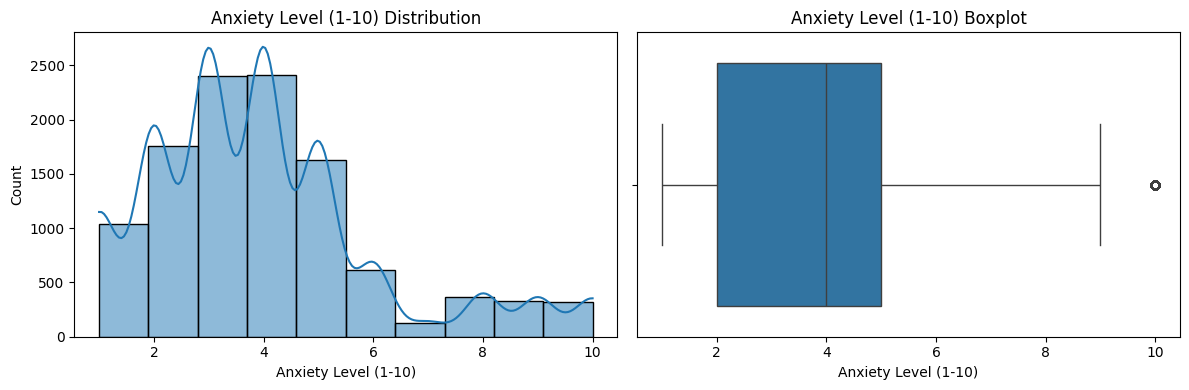


Target Variable Distribution: Stress Level (1-10)
count    11000.000000
mean         5.856364
std          2.927202
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Stress Level (1-10), dtype: float64



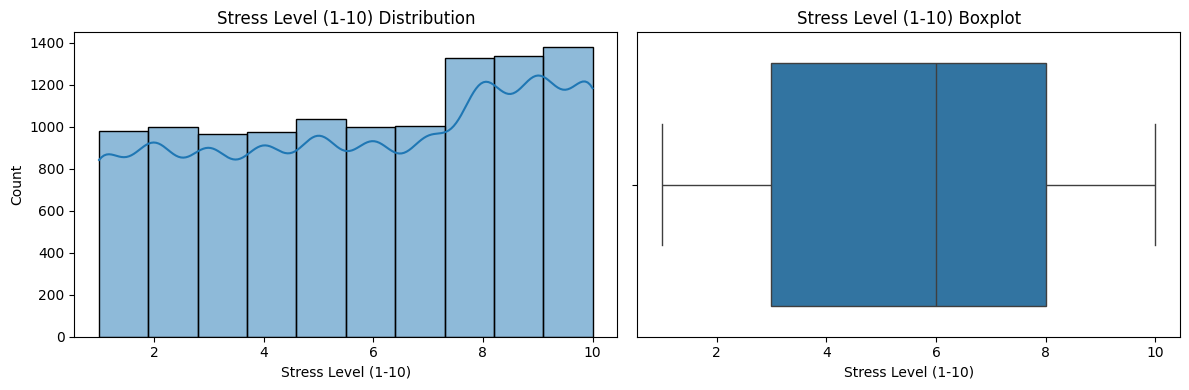

In [202]:
targets = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

for target in targets:
    print(f"\nTarget Variable Distribution: {target}")
    print(data[target].describe())
    print("\n" + "="*60)

    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[target], bins=10, kde=True)
    plt.title(f'{target} Distribution')
    plt.xlabel(target)
    plt.ylabel('Count')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[target])
    plt.title(f'{target} Boxplot')

    plt.tight_layout()
    plt.show()

Number of numerical features: 17
Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='object')


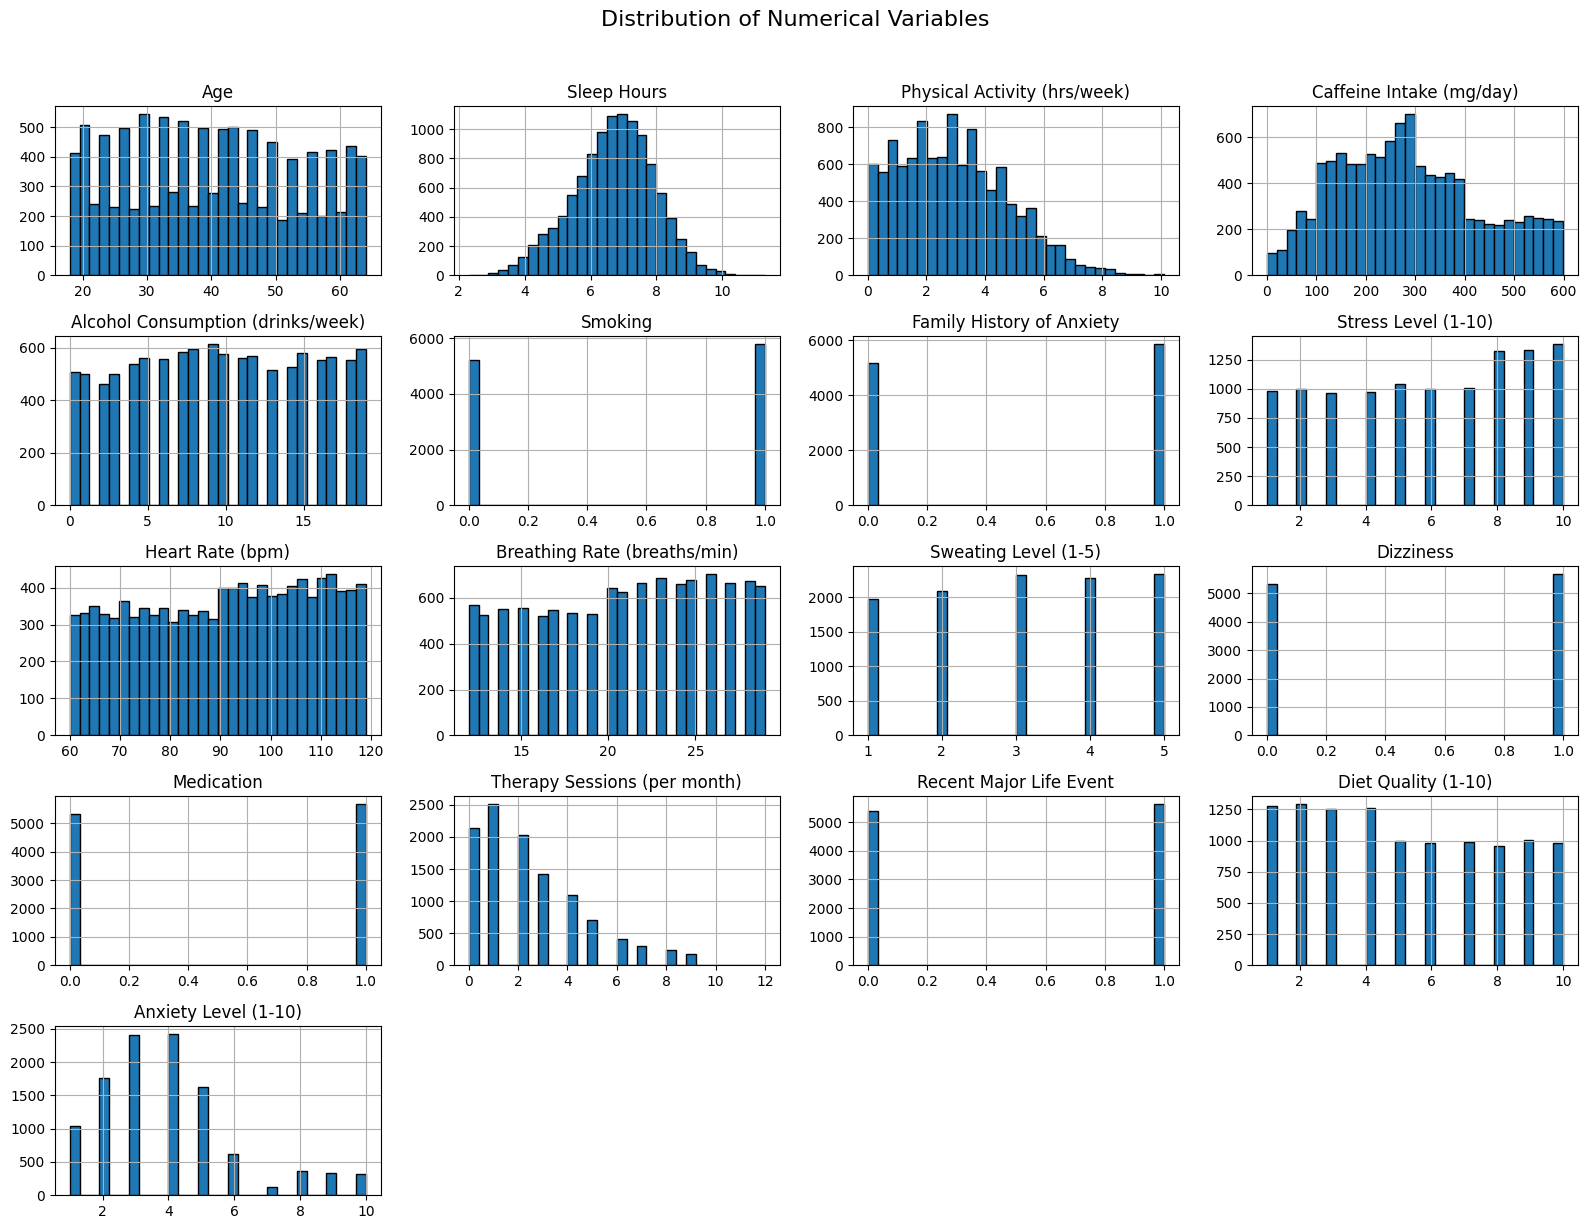

Skewness and Kurtosis Analysis:
                                   Skewness  Kurtosis
Anxiety Level (1-10)               1.043996  0.950054
Therapy Sessions (per month)       1.035117  0.586923
Physical Activity (hrs/week)       0.507010 -0.215078
Caffeine Intake (mg/day)           0.323941 -0.701446
Sleep Hours                       -0.224472 -0.047568
Diet Quality (1-10)                0.161948 -1.228529
Stress Level (1-10)               -0.160872 -1.255731
Breathing Rate (breaths/min)      -0.141205 -1.171865
Family History of Anxiety         -0.126451 -1.984371
Heart Rate (bpm)                  -0.119204 -1.192624
Smoking                           -0.101599 -1.990039
Age                                0.097336 -1.126341
Sweating Level (1-5)              -0.073929 -1.263226
Dizziness                         -0.062585 -1.996446
Medication                        -0.060399 -1.996715
Recent Major Life Event           -0.044745 -1.998361
Alcohol Consumption (drinks/week) -0.023334 -1.159

In [203]:
numerical_cols = data.select_dtypes(include=[np.number]).columns
print(f"Number of numerical features: {len(numerical_cols)}")
print(numerical_cols)

# Histograms for all numerical variables
data[numerical_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    'Distribution of Numerical Variables',
    y=1.02,
    fontsize=16
)
plt.tight_layout()
plt.show()

# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': data[numerical_cols].skew(),
    'Kurtosis': data[numerical_cols].kurtosis()
}).sort_values(by='Skewness', key=abs, ascending=False)

print("Skewness and Kurtosis Analysis:")
print(skew_kurt)
print("\n" + "=" * 60)

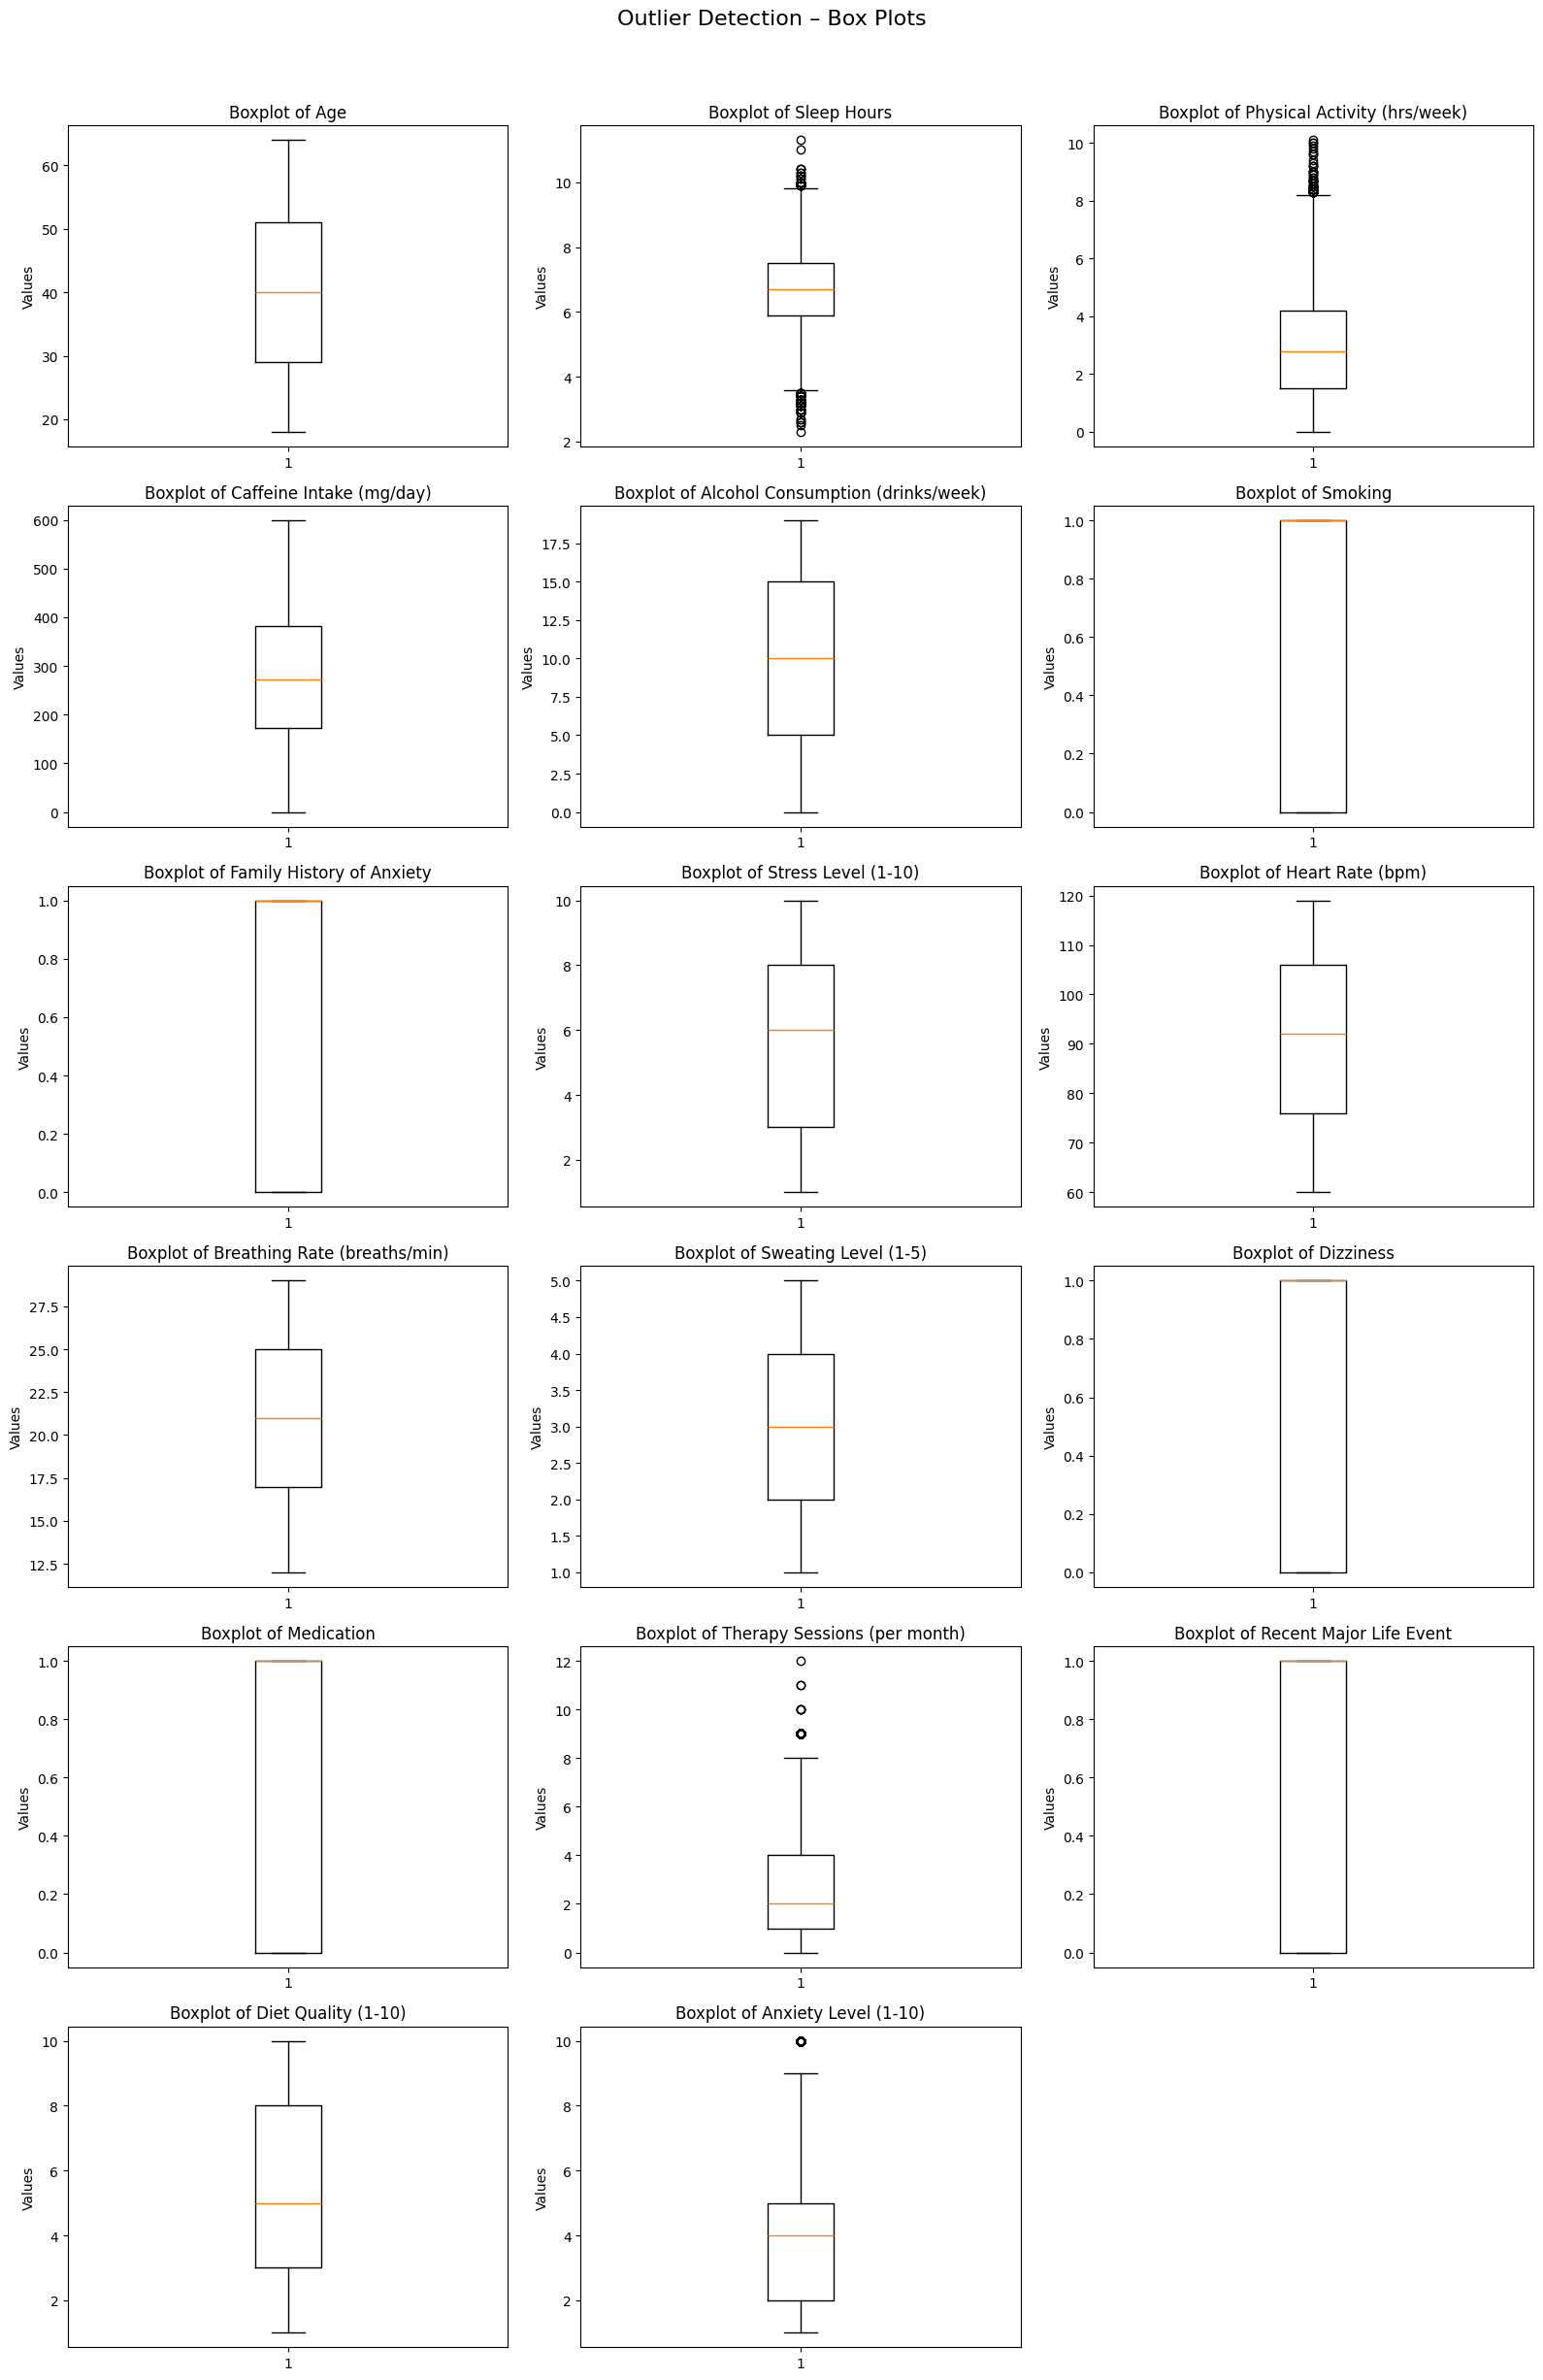

Outlier Summary (IQR Method):
                                   Outlier Count  Outlier Percentage (%)  \
Anxiety Level (1-10)                       322.0                2.927273   
Therapy Sessions (per month)               178.0                1.618182   
Sleep Hours                                110.0                1.000000   
Physical Activity (hrs/week)                56.0                0.509091   
Age                                          0.0                0.000000   
Smoking                                      0.0                0.000000   
Family History of Anxiety                    0.0                0.000000   
Caffeine Intake (mg/day)                     0.0                0.000000   
Alcohol Consumption (drinks/week)            0.0                0.000000   
Heart Rate (bpm)                             0.0                0.000000   
Stress Level (1-10)                          0.0                0.000000   
Breathing Rate (breaths/min)                 0.0          

In [204]:
# Select numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns

# -------------------------------
# Box plots for visual detection
# -------------------------------
n_cols = 3
n_rows = len(numerical_cols) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(data[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel('Values')

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Outlier Detection – Box Plots', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------------
# IQR-based outlier quantification
# -------------------------------
outliers_summary = {}

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]

    outliers_summary[col] = {
        'Outlier Count': len(outliers),
        'Outlier Percentage (%)': (len(outliers) / len(data)) * 100,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Min Value': data[col].min(),
        'Max Value': data[col].max()
    }

outliers_df = (
    pd.DataFrame(outliers_summary)
    .T
    .sort_values('Outlier Percentage (%)', ascending=False)
)

print("Outlier Summary (IQR Method):")
print(outliers_df)
print("\n" + "=" * 60)

In [205]:
# ----------------------------
# Step 0: Normalize column names
# ----------------------------
data.columns = [col.replace('–', '-').strip() for col in data.columns]
print("Normalized Columns:")
print(data.columns.tolist())


# ----------------------------
# Step 2: Comprehensive Statistical Summary Function
# ----------------------------
def create_comprehensive_summary(data, target_cols):
    """Generate a detailed statistical summary for numeric, categorical, and targets"""
    
    summary = {}
    
    # ----------------------------
    # Dataset Overview
    # ----------------------------
    summary['Dataset_Overview'] = {
        'Total_Samples': len(data),
        'Total_Features': len(data.columns),
        'Numerical_Features': len(data.select_dtypes(include=[np.number]).columns),
        'Categorical_Features': len(data.select_dtypes(include=['object', 'category']).columns),
        'Missing_Values_Total': int(data.isnull().sum().sum()),
        'Missing_Values_Percentage': round((data.isnull().sum().sum() / (len(data) * len(data.columns))) * 100, 2)
    }
    
    # ----------------------------
    # Target Variable Summary
    # ----------------------------
    summary['Targets'] = {}
    for target_col in target_cols:
        summary['Targets'][target_col] = {
            'Type': str(data[target_col].dtype),
            'Missing_Values': int(data[target_col].isnull().sum())
        }
        if data[target_col].dtype in [np.int64, np.float64]:
            summary['Targets'][target_col].update({
                'Mean': data[target_col].mean(),
                'Median': data[target_col].median(),
                'Std': data[target_col].std(),
                'Min': data[target_col].min(),
                'Max': data[target_col].max(),
                'Skewness': data[target_col].skew(),
                'Kurtosis': data[target_col].kurtosis()
            })
        else:
            summary['Targets'][target_col].update({
                'Class_Distribution': dict(data[target_col].value_counts()),
                'Percentage_Distribution': dict((data[target_col].value_counts(normalize=True)*100).round(2))
            })
    
    # ----------------------------
    # Numerical Features Summary
    # ----------------------------
    numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    summary['Numerical_Features'] = {}
    for col in numerical_cols:
        col_data = data[col].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
        
        summary['Numerical_Features'][col] = {
            'Mean': col_data.mean(),
            'Median': col_data.median(),
            'Std': col_data.std(),
            'Min': col_data.min(),
            'Max': col_data.max(),
            'Skewness': col_data.skew(),
            'Kurtosis': col_data.kurtosis(),
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': round(len(outliers)/len(col_data)*100, 2)
        }
    
    # ----------------------------
    # Categorical Features Summary
    # ----------------------------
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
    summary['Categorical_Features'] = {}
    for col in categorical_cols:
        summary['Categorical_Features'][col] = {
            'Unique_Values': data[col].nunique(),
            'Top_Values': dict(data[col].value_counts().head(5))
        }
    
    # ----------------------------
    # Data Quality
    # ----------------------------
    summary['Data_Quality'] = {
        'Duplicate_Rows': int(data.duplicated().sum()),
        'Constant_Columns': [col for col in data.columns if data[col].nunique() == 1],
        'High_Cardinality_Columns': [col for col in data.columns if data[col].nunique() > 50]
    }
    
    # ----------------------------
    # Feature Significance with Targets
    # ----------------------------
    summary['Feature_Significance'] = {}
    
    for target in target_cols:
        summary['Feature_Significance'][target] = {'Numerical': [], 'Categorical': []}
        
        # Numerical: Pearson correlation
        for col in numerical_cols:
            if col != target:
                valid_data = data[[col, target]].dropna()
                if len(valid_data) > 2:
                    corr, p_val = stats.pearsonr(valid_data[col], valid_data[target])
                    if p_val < 0.05:
                        summary['Feature_Significance'][target]['Numerical'].append(
                            {'Feature': col, 'Correlation': round(corr,3), 'p-value': round(p_val,4)}
                        )
        
        # Categorical: ANOVA
        for col in categorical_cols:
            valid_data = data[[col, target]].dropna()
            groups = [valid_data[valid_data[col]==cat][target] for cat in valid_data[col].unique()]
            if len(groups) > 1:
                f_stat, p_val = stats.f_oneway(*groups)
                if p_val < 0.05:
                    summary['Feature_Significance'][target]['Categorical'].append(
                        {'Feature': col, 'F-statistic': round(f_stat,3), 'p-value': round(p_val,4)}
                    )
    
    return summary

# ----------------------------
# Step 3: Generate report for Stress and Anxiety
# ----------------------------
summary_report = create_comprehensive_summary(
    data, 
    target_cols=['Stress Level (1-10)', 'Anxiety Level (1-10)']
)

# ----------------------------
# Step 4: Print summary neatly
# ----------------------------
print("COMPREHENSIVE STATISTICAL REPORT")
print("="*80)

for section, content in summary_report.items():
    print(f"\n{section.replace('_',' ').title()}:")
    print("-"*60)
    if isinstance(content, dict):
        for key, value in content.items():
            print(f"\n{key}:")
            if isinstance(value, dict):
                for subkey, subval in value.items():
                    print(f"  {subkey}: {subval}")
            else:
                print(f"  {value}")
    else:
        print(content)


Normalized Columns:
['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']


COMPREHENSIVE STATISTICAL REPORT

Dataset Overview:
------------------------------------------------------------

Total_Samples:
  11000

Total_Features:
  19

Numerical_Features:
  17

Categorical_Features:
  2

Missing_Values_Total:
  0

Missing_Values_Percentage:
  0.0

Targets:
------------------------------------------------------------

Stress Level (1-10):
  Type: int64
  Missing_Values: 0
  Mean: 5.856363636363636
  Median: 6.0
  Std: 2.9272019381941194
  Min: 1
  Max: 10
  Skewness: -0.16087188894468468
  Kurtosis: -1.2557311164396465

Anxiety Level (1-10):
  Type: float64
  Missing_Values: 0
  Mean: 3.9293636363636364
  Median: 4.0
  Std: 2.122533235477882
  Min: 1.0
  Max: 10.0
  Skewness: 1.0439964647889457
  Kurtosis: 0.950053926739526

Numerical Features:
------------------------------------------------------------

Age:
  Mean: 40.241727272727275
  Median: 40.0
  Std: 13.236140066931384
  Min: 18
  Max: 64
  Skewness: 0.09733621216388642
  Kurtosis: -1.1263406319227574
 

In [206]:
data.to_csv("clean.csv", index=False)
print("CSV file successfully saved")


CSV file successfully saved


Implementing the machine learning model

Importing the required models

In [207]:
# # --------------------------
# # Binary Logistic Regression: Anxiety Prediction with Probabilities & Visualization
# # --------------------------

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# # --------------------------
# # 1. Assume your data is already in 'data'
# # --------------------------
# # data = pd.read_csv('your_data.csv')  # Not needed if 'data' already exists

# # --------------------------
# # 2. Define binary target
# # --------------------------
# data['Has_Anxiety'] = (data['Anxiety Level (1-10)'] >= 5).astype(int)

# # --------------------------
# # 3. Separate features and target
# # --------------------------
# X = data.drop(['Anxiety Level (1-10)', 'Has_Anxiety'], axis=1)
# y = data['Has_Anxiety']

# # --------------------------
# # 4. Identify categorical and numeric columns
# # --------------------------
# cat_cols = ['Gender', 'Occupation']  # One-hot encode these
# num_cols = [c for c in X.columns if c not in cat_cols]  # Scale these

# # --------------------------
# # 5. Preprocessing & pipeline
# # --------------------------
# preprocess = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols),
#         ('cat', OneHotEncoder(drop='first'), cat_cols)
#     ]
# )

# model = Pipeline([
#     ('preprocess', preprocess),
#     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
# ])

# # --------------------------
# # 6. Train-test split
# # --------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # --------------------------
# # 7. Train the model
# # --------------------------
# model.fit(X_train, y_train)

# # --------------------------
# # 8. Predict probabilities & classes
# # --------------------------
# y_prob = model.predict_proba(X_test)[:, 1]  # Probability of Has_Anxiety = 1
# y_pred = model.predict(X_test)              # Predicted class

# # --------------------------
# # 9. Add predictions to DataFrame
# # --------------------------
# X_test_df = X_test.copy()
# X_test_df['Predicted_Probability'] = y_prob
# X_test_df['Predicted_Class'] = y_pred
# X_test_df['True_Label'] = y_test.values

# print("First 10 rows of test set with predictions:")
# print(X_test_df.head(10))

# # --------------------------
# # 10. Evaluate the model
# # --------------------------
# roc_auc = roc_auc_score(y_test, y_prob)
# accuracy = accuracy_score(y_test, y_pred)
# logloss = log_loss(y_test, y_prob)

# print("\nLogistic Regression Binary Classification Results")
# print("-------------------------------------------------")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Log Loss: {logloss:.4f}")

# # --------------------------
# # 11. Optional: 5-fold cross-validation for ROC-AUC
# # --------------------------
# cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
# print("\n5-Fold CV ROC-AUC: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

# # --------------------------
# # 12. ROC Curve
# # --------------------------
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# roc_auc_val = auc(fpr, tpr)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.2f})')
# plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.show()

# # --------------------------
# # 13. Predicted Probability Distribution
# # --------------------------
# plt.figure(figsize=(6,4))
# plt.hist(y_prob[y_test==0], bins=20, alpha=0.5, label='No Anxiety')
# plt.hist(y_prob[y_test==1], bins=20, alpha=0.5, label='Has Anxiety')
# plt.xlabel('Predicted Probability')
# plt.ylabel('Count')
# plt.title('Predicted Probability Distribution')
# plt.legend()
# plt.show()

# # --------------------------
# # 14. Confusion Matrix
# # --------------------------
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# disp.plot(cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()


In [208]:
# # --------------------------
# # Binary Classification with XGBoost
# # --------------------------

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
# from xgboost import XGBClassifier

# # --------------------------
# # 1. Binary target
# # --------------------------
# data['Has_Anxiety'] = (data['Anxiety Level (1-10)'] >= 5).astype(int)

# X = data.drop(['Anxiety Level (1-10)', 'Has_Anxiety'], axis=1)
# y = data['Has_Anxiety']

# # --------------------------
# # 2. Identify categorical and numeric columns
# # --------------------------
# cat_cols = ['Gender', 'Occupation']  # one-hot encode
# num_cols = [c for c in X.columns if c not in cat_cols]  # scale numeric

# # --------------------------
# # 3. Preprocessing & pipeline
# # --------------------------
# preprocess = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols),
#         ('cat', OneHotEncoder(drop='first'), cat_cols)
#     ]
# )

# xgb_model = Pipeline([
#     ('preprocess', preprocess),
#     ('clf', XGBClassifier(
#         n_estimators=300,       # number of trees
#         learning_rate=0.01,     # smaller learning rate for stability
#         max_depth=4,
#         use_label_encoder=False,
#         eval_metric='logloss',
#         random_state=42
#     ))
# ])

# # --------------------------
# # 4. Train-test split
# # --------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # --------------------------
# # 5. Train the model
# # --------------------------
# xgb_model.fit(X_train, y_train)

# # --------------------------
# # 6. Predict probabilities & classes
# # --------------------------
# y_prob = xgb_model.predict_proba(X_test)[:, 1]
# y_pred = xgb_model.predict(X_test)

# # --------------------------
# # 7. Add predictions to DataFrame
# # --------------------------
# X_test_df = X_test.copy()
# X_test_df['Predicted_Probability'] = y_prob
# X_test_df['Predicted_Class'] = y_pred
# X_test_df['True_Label'] = y_test.values

# print("First 10 rows of test set with predictions:")
# print(X_test_df.head(10))

# # --------------------------
# # 8. Evaluate the model
# # --------------------------
# roc_auc = roc_auc_score(y_test, y_prob)
# accuracy = accuracy_score(y_test, y_pred)
# logloss = log_loss(y_test, y_prob)

# print("\nXGBoost Binary Classification Results")
# print("------------------------------------")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Log Loss: {logloss:.4f}")

# # --------------------------
# # 9. Optional: 5-fold cross-validation for ROC-AUC
# # --------------------------
# cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='roc_auc')
# print("\n5-Fold CV ROC-AUC: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

# # --------------------------
# # 10. ROC Curve
# # --------------------------
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# roc_auc_val = auc(fpr, tpr)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.2f})')
# plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.show()

# # --------------------------
# # 11. Predicted Probability Distribution
# # --------------------------
# plt.figure(figsize=(6,4))
# plt.hist(y_prob[y_test==0], bins=20, alpha=0.5, label='No Anxiety')
# plt.hist(y_prob[y_test==1], bins=20, alpha=0.5, label='Has Anxiety')
# plt.xlabel('Predicted Probability')
# plt.ylabel('Count')
# plt.title('Predicted Probability Distribution')
# plt.legend()
# plt.show()

# # --------------------------
# # 12. Confusion Matrix
# # --------------------------
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# disp.plot(cmap='Greens')
# plt.title('Confusion Matrix')
# plt.show()


In [209]:
# # --------------------------
# # Binary Classification with Neural Network
# # --------------------------

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# # --------------------------
# # 1. Binary target
# # --------------------------
# data['Has_Anxiety'] = (data['Anxiety Level (1-10)'] >= 5).astype(int)

# X = data.drop(['Anxiety Level (1-10)', 'Has_Anxiety'], axis=1)
# y = data['Has_Anxiety']

# # --------------------------
# # 2. Identify categorical and numeric columns
# # --------------------------
# cat_cols = ['Gender', 'Occupation']  # one-hot encode
# num_cols = [c for c in X.columns if c not in cat_cols]  # scale numeric

# # --------------------------
# # 3. Preprocessing
# # --------------------------
# preprocess = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols),
#         ('cat', OneHotEncoder(drop='first'), cat_cols)
#     ]
# )

# # Preprocess features
# X_processed = preprocess.fit_transform(X)

# # --------------------------
# # 4. Train-test split
# # --------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X_processed, y, test_size=0.2, random_state=42, stratify=y
# )

# # --------------------------
# # 5. Build neural network
# # --------------------------
# input_dim = X_train.shape[1]

# nn_model = Sequential([
#     Dense(32, input_dim=input_dim, activation='relu'),
#     Dropout(0.2),
#     Dense(16, activation='relu'),
#     Dropout(0.1),
#     Dense(1, activation='sigmoid')  # output probability
# ])

# nn_model.compile(optimizer=Adam(learning_rate=0.001),
#                  loss='binary_crossentropy',
#                  metrics=['accuracy'])

# # --------------------------
# # 6. Train the model
# # --------------------------
# history = nn_model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=32,
#     verbose=1
# )

# # --------------------------
# # 7. Predict probabilities & classes
# # --------------------------
# y_prob = nn_model.predict(X_test).flatten()
# y_pred = (y_prob >= 0.5).astype(int)

# # --------------------------
# # 8. Evaluate the model
# # --------------------------
# roc_auc = roc_auc_score(y_test, y_prob)
# accuracy = accuracy_score(y_test, y_pred)
# logloss = log_loss(y_test, y_prob)

# print("\nNeural Network Binary Classification Results")
# print("-------------------------------------------")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Log Loss: {logloss:.4f}")

# # --------------------------
# # 9. ROC Curve
# # --------------------------
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# roc_auc_val = auc(fpr, tpr)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.2f})')
# plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend(loc='lower right')
# plt.show()

# # --------------------------
# # 10. Predicted Probability Distribution
# # --------------------------
# plt.figure(figsize=(6,4))
# plt.hist(y_prob[y_test==0], bins=20, alpha=0.5, label='No Anxiety')
# plt.hist(y_prob[y_test==1], bins=20, alpha=0.5, label='Has Anxiety')
# plt.xlabel('Predicted Probability')
# plt.ylabel('Count')
# plt.title('Predicted Probability Distribution')
# plt.legend()
# plt.show()

# # --------------------------
# # 11. Confusion Matrix
# # --------------------------
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# disp.plot(cmap='Purples')
# plt.title('Confusion Matrix')
# plt.show()


In [210]:
def imbalance_ratio(series):
    counts = series.value_counts()
    majority = counts.max()
    minority = counts.min()
    ratio = majority / minority
    return ratio

# Use it on your target
ratio = imbalance_ratio(data['Has_Anxiety'])
print(f"Imbalance ratio: {ratio:.2f}")
print(f"Majority:Minority ≈ {ratio:.1f}:1")


KeyError: 'Has_Anxiety'

In [ ]:
print(data['Has_Anxiety'].value_counts(normalize=True))


Has_Anxiety
0    0.692545
1    0.307455
Name: proportion, dtype: float64


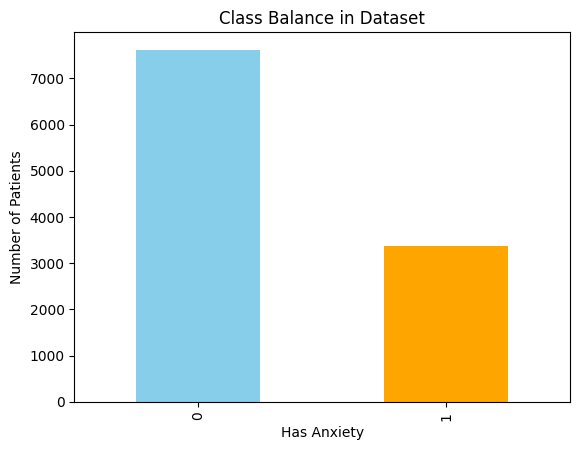

In [ ]:
import matplotlib.pyplot as plt

data['Has_Anxiety'].value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.xlabel('Has Anxiety')
plt.ylabel('Number of Patients')
plt.title('Class Balance in Dataset')
plt.show()
